In [1]:
import numpy as np
import diffrax
import matplotlib.pyplot as plt
import matplotlib as mpl
import met_brewer as mb
import seaborn as sns
import jax
import sys

sys.path.append("../")
from utils import *
from plotting_helper_funcs import *

sys.path.append("../models/")

# tell jax to use 64bit floats
jax.config.update("jax_enable_x64", True)

plt.style.use('custom')
mpl.rcParams['figure.autolayout'] = True
colors = mb.met_brew(name="Egypt", n=3)


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [42]:
ADVI = az.from_netcdf('../../../results/param_est/MM_single_cyto_mcmc_samples_ADVI.nc')
MCMC = az.from_netcdf('../../../results/param_est/MM_single_cyto_mcmc_samples_Nutpie.nc')

ADVI_kOffADP = np.squeeze(ADVI.posterior['kOffADP'].values)
MCMC_kOffADP = np.squeeze(MCMC.posterior['kOffADP'].values.reshape(1, 4000))

combined_inference_data = az.from_dict({
        "ADVI_kOffADP": ADVI_kOffADP,
        "MCMC_kOffADP": MCMC_kOffADP
})

combined_inference_data

Inference data with groups:
	> posterior

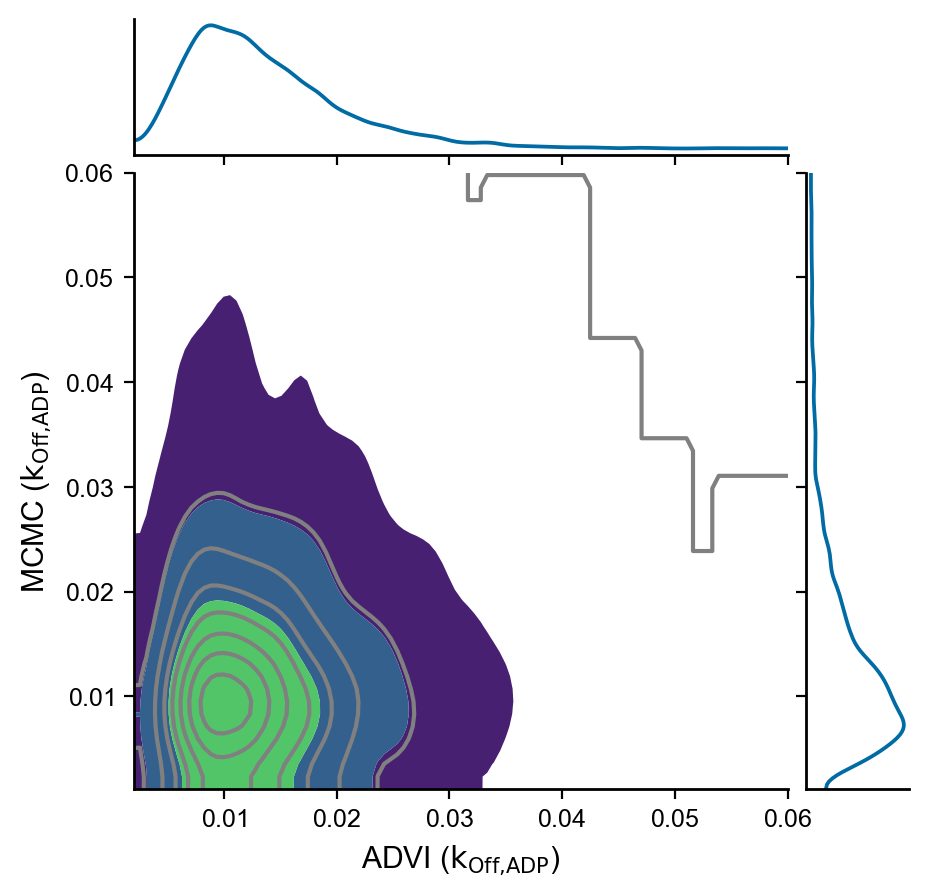

In [53]:
axs = az.plot_pair(combined_inference_data, kind='kde', marginals=True, figsize=(5, 5))
axs[1][0].set_xlabel(r'ADVI ($k_{\text{Off,ADP}}$)')
axs[1][0].set_ylabel(r'MCMC ($k_{\text{Off,ADP}}$)')
xlim = axs[1][0].get_xlim()
ylim = axs[1][0].get_ylim()
axs[1][0].set_xlim(xlim[0], 0.06)
axs[1][0].set_ylim(ylim[0], 0.06)
axs[1][0].ticklabel_format(style='plain', axis='y')

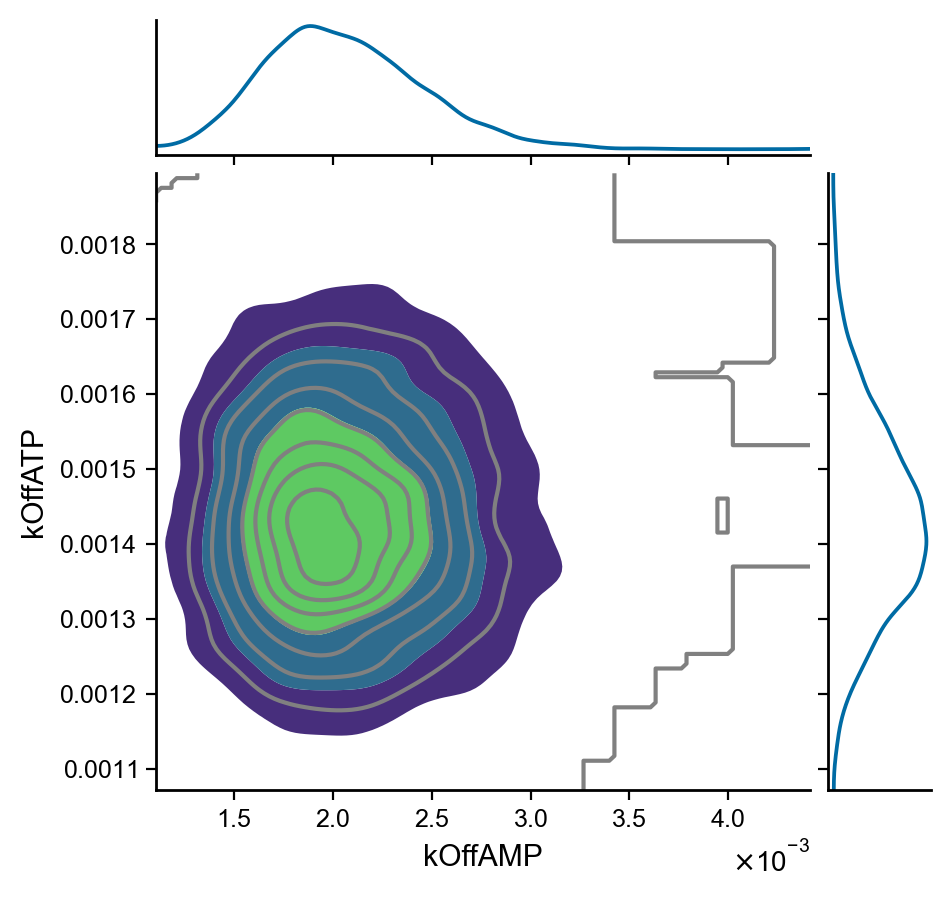

In [59]:
axs = az.plot_pair(ADVI, var_names=['kOffAMP', 'kOffATP'], kind='kde', marginals=True, figsize=(5, 5))
xlim = axs[1][0].get_xlim()
ylim = axs[1][0].get_ylim()
axs[1][0].ticklabel_format(style='plain', axis='y')

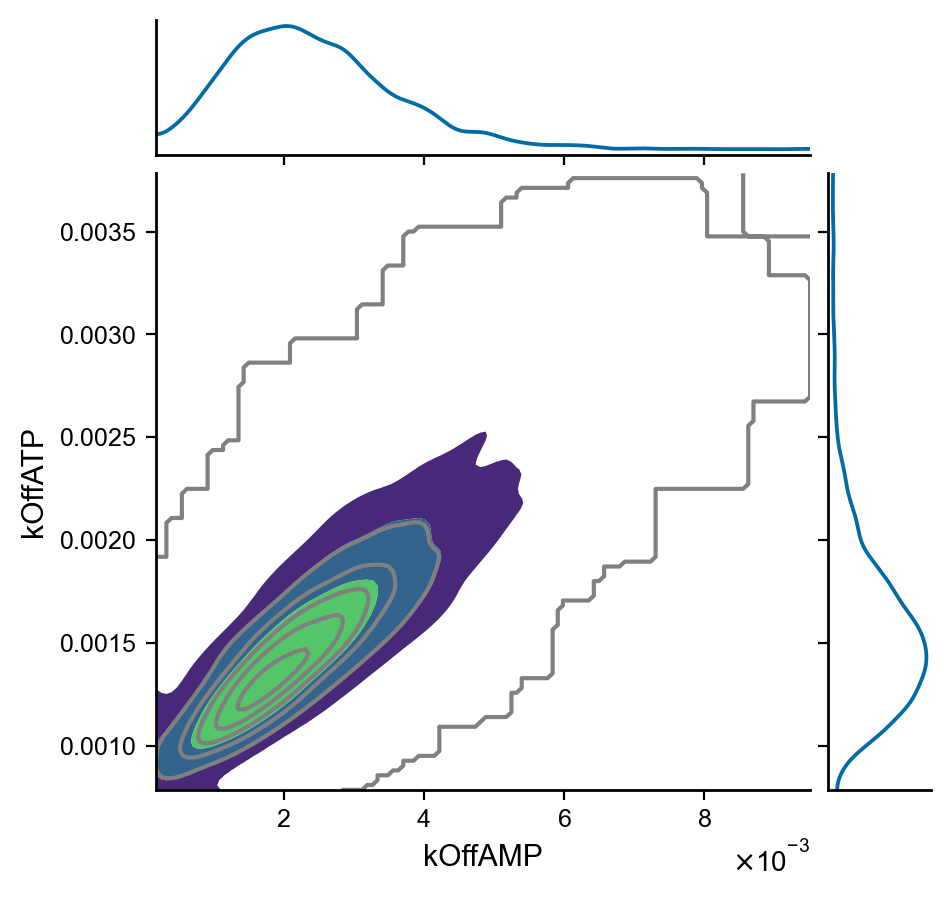

In [58]:
axs = az.plot_pair(MCMC, var_names=['kOffAMP', 'kOffATP'], kind='kde', marginals=True, figsize=(5, 5))
xlim = axs[1][0].get_xlim()
ylim = axs[1][0].get_ylim()
axs[1][0].ticklabel_format(style='plain', axis='y')